# SKA-like drift scan across the galactic plane (experiment 003)

Sidelobe stress test for the drift-scan strategy. Identical telescope, beams,
noise (same per-night seeds), and map-making recipe as `ska_drift_scan.ipynb`
(experiments 001/002) — the **only change is the LST window**: the same
az = 0°, el = 52°/50°/48° drift now starts at LST ≈ 280°, so the Dec ≈ +9°
strip sweeps galactic latitude **b = +7° → −6°**, crossing the plane
mid-window at l ≈ 43° (inner galaxy, several hundred K at 350 MHz).

Experiment 002 found that unmodelled −23 dB sidelobes cost essentially nothing
at b ≈ +50° (mismatch ≡ matched-gauss to ~3 mK, buried under ~2.4 K of 1/f
residual). Here the sidelobe rings sweep coherently through emission 10–100×
brighter, so that null result gets its proper test. Same three scenarios:

1. **gauss** — matched Gaussian forward/inverse (idealised control).
2. **airy** — matched tapered-aperture forward/inverse (modelled sidelobes).
3. **mismatch** — tapered-aperture sky through the Gaussian operator
   (*unmodelled* sidelobes, the realistic survey case). Shares the gauss
   operator, mask, prior, and noise realization — the mismatch-vs-gauss
   difference is purely the unmodelled sidelobe pickup.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', '..')))
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', 'DSA')))

import pickle
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
from astropy.coordinates import EarthLocation
from astropy import units as u

from limTOD import TODSim, HPW_mapmaking
from ska_common import (SKA_LAT, SKA_LON, SKA_HGT, ska_beam_func,
                        gdsm_equatorial_sky_model,
                        ska_airy_beam_func, ska_beam_fwhm_deg,
                        tapered_aperture_fwhm_deg,
                        drift_scan_night, azel_to_radec, save_results_pdf)
from dsa_vis import plot_map_compare


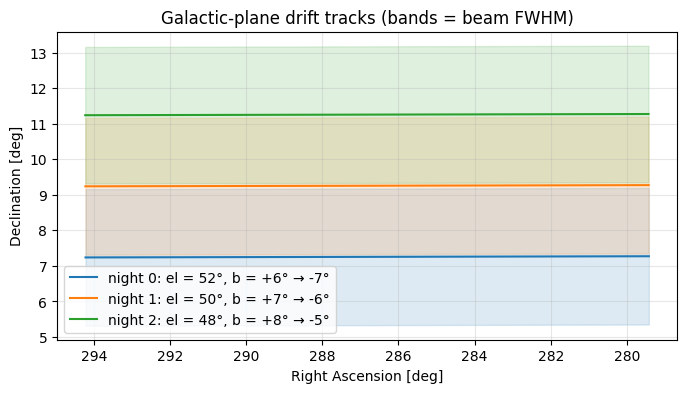

In [2]:
# Identical configuration to ska_drift_scan.ipynb ...
freq_list = [350]  # MHz
BEAMS = {
    "gauss": dict(func=ska_beam_func,
                  fwhm=ska_beam_fwhm_deg(freq_list[0]),
                  label="Gaussian (1.22 λ/D)"),
    "airy": dict(func=ska_airy_beam_func,
                 fwhm=tapered_aperture_fwhm_deg(freq_list[0]),
                 label="Tapered aperture (−14 dB edge taper)"),
}
sky_Nside = 64
beam_Nside = 64
sky_Nside_map = 64
truncate_frac_thres = 1e-5
SEED = 0
WHITE_VAR = 2.5e-6

DRIFT_AZ = 0.0
ELEVATIONS = [52.0, 50.0, 48.0]
NIGHT_DURATION_S = 3600.0
DT = 2.0

# ... except the start time: LST ≈ 280° puts the plane crossing (l ≈ 43°,
# RA ≈ 288°, Dec ≈ +9°) in the middle of the 15°-wide drift window.
START_UTC = "2024-04-16 03:34:00"

site = EarthLocation(lat=SKA_LAT * u.deg, lon=SKA_LON * u.deg,
                     height=SKA_HGT * u.m)

nights = []
for night, el in enumerate(ELEVATIONS):
    tlist, azlist = drift_scan_night(NIGHT_DURATION_S, dt=DT,
                                     night=night, azimuth_deg=DRIFT_AZ)
    nights.append(dict(night=night, el=el, tlist=tlist, azlist=azlist))

# Boresight tracks over the GDSM patch: the plane crossing is obvious.
from astropy.coordinates import SkyCoord
fwhm_ref = BEAMS["airy"]["fwhm"]
fig, ax = plt.subplots(figsize=(8, 4))
for n in nights:
    ra, dec = azel_to_radec(DRIFT_AZ, n["el"], n["tlist"][::30],
                            START_UTC, site)
    b_gal = SkyCoord(ra=ra * u.deg, dec=dec * u.deg).galactic.b.deg
    line, = ax.plot(ra, dec, lw=1.5,
                    label=f"night {n['night']}: el = {n['el']:.0f}°, "
                          f"b = {b_gal[0]:+.0f}° → {b_gal[-1]:+.0f}°")
    ax.fill_between(ra, dec - fwhm_ref / 2, dec + fwhm_ref / 2,
                    alpha=0.15, color=line.get_color())
ax.set_xlabel("Right Ascension [deg]")
ax.set_ylabel("Declination [deg]")
ax.invert_xaxis()
ax.set_title("Galactic-plane drift tracks (bands = beam FWHM)")
ax.legend()
ax.grid(alpha=0.3)
os.makedirs("figures", exist_ok=True)
fig.savefig("figures/galplane_drift_tracks.png", dpi=200,
            bbox_inches="tight")
plt.show()


[gauss] loaded 3 cached TODs from simulated_TODs_ska_drift_galplane_gauss.npz
[airy] loaded 3 cached TODs from simulated_TODs_ska_drift_galplane_airy.npz


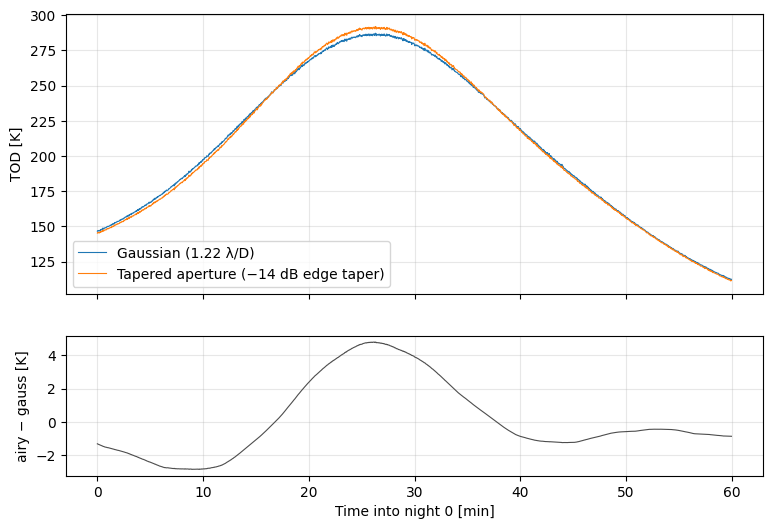

In [3]:
# Simulate one TOD per night per beam (caches tagged _galplane).
tod_data = {}
for tag, b in BEAMS.items():
    cache = f"simulated_TODs_ska_drift_galplane_{tag}.npz"
    try:
        data = np.load(cache, allow_pickle=True)
        tod_data[tag] = dict(
            TOD_group=[np.asarray(t, np.float64) for t in data["TOD_group"]],
            LST_deg_list_group=[np.asarray(x, np.float64)
                                for x in data["LST_deg_list_group"]],
            azimuth_deg_list_group=[np.asarray(x, np.float64)
                                    for x in data["azimuth_deg_list_group"]],
            elevation_deg_list_group=[np.asarray(x, np.float64)
                                      for x in data["elevation_deg_list_group"]],
        )
        print(f"[{tag}] loaded {len(tod_data[tag]['TOD_group'])} cached "
              f"TODs from {cache}")
        continue
    except (FileNotFoundError, KeyError):
        pass

    tod_sim = TODSim(
        ant_latitude_deg=SKA_LAT,
        ant_longitude_deg=SKA_LON,
        ant_height_m=SKA_HGT,
        beam_func=b["func"],
        sky_func=gdsm_equatorial_sky_model,
        beam_nside=beam_Nside,
        sky_nside=sky_Nside,
    )
    groups = dict(TOD_group=[], LST_deg_list_group=[],
                  azimuth_deg_list_group=[], elevation_deg_list_group=[])
    print(f"[{tag}] generating simulated TODs (one per night)...")
    for n in nights:
        # Same seed per night across beams — identical noise realizations.
        np.random.seed(SEED + n["night"])
        tod_array, _, _, lst_deg = tod_sim.generate_TOD(
            freq_list=freq_list,
            time_list=n["tlist"],
            azimuth_deg_list=n["azlist"],
            elevation_deg=n["el"],
            start_time_utc=START_UTC,
            white_noise_var=WHITE_VAR,
            return_LSTs=True,
            normalize_beam=False,
            truncate_frac_thres=truncate_frac_thres,
        )
        groups["TOD_group"].append(np.asarray(tod_array[0], np.float64))
        groups["LST_deg_list_group"].append(np.asarray(lst_deg, np.float64))
        groups["azimuth_deg_list_group"].append(
            np.asarray(n["azlist"], np.float64))
        groups["elevation_deg_list_group"].append(
            n["el"] * np.ones_like(groups["TOD_group"][-1]))
    np.savez(cache, freq_list=freq_list, **groups)
    tod_data[tag] = groups
    print(f"[{tag}] done! Saved to {cache}")

# Night-0 TOD: the plane crossing dominates; the gauss/airy difference now
# shows the sidelobes loading in plane emission well before/after the main
# lobe crosses it. Log inset of the |difference| makes that visible.
fig, (ax, axd) = plt.subplots(2, 1, figsize=(9, 6), sharex=True,
                              height_ratios=[2, 1])
for tag, b in BEAMS.items():
    ax.plot(nights[0]["tlist"] / 60.0, tod_data[tag]["TOD_group"][0],
            lw=0.8, label=b["label"])
ax.set_ylabel("TOD [K]")
ax.legend()
ax.grid(alpha=0.3)
diff = (tod_data["airy"]["TOD_group"][0]
        - tod_data["gauss"]["TOD_group"][0])
axd.plot(nights[0]["tlist"] / 60.0, diff, lw=0.8, color="0.3")
axd.set_xlabel("Time into night 0 [min]")
axd.set_ylabel("airy − gauss [K]")
axd.grid(alpha=0.3)
fig.savefig("figures/galplane_tod_night0.png", dpi=200,
            bbox_inches="tight")
plt.show()


In [4]:
# Operators per beam (cached, tagged _galplane).
mapmakers = {}
for tag, b in BEAMS.items():
    cache = f"mapmaker_ops_ska_drift_galplane_{tag}_ns{sky_Nside_map}.pkl"
    try:
        with open(cache, "rb") as f:
            mapmakers[tag] = pickle.load(f)
        print(f"[{tag}] loaded cached HPW_mapmaker operator from {cache}")
        continue
    except (FileNotFoundError, EOFError):
        pass
    beam_map = b["func"](freq=freq_list[0], nside=beam_Nside)
    mapmakers[tag] = HPW_mapmaking(
        beam_map=beam_map,
        LST_deg_list_group=tod_data[tag]["LST_deg_list_group"],
        lat_deg=SKA_LAT,
        azimuth_deg_list_group=tod_data[tag]["azimuth_deg_list_group"],
        elevation_deg_list_group=tod_data[tag]["elevation_deg_list_group"],
        threshold=0.05,
        nside_target=sky_Nside_map,
        beam_truncate_frac_thres=truncate_frac_thres,
    )
    with open(cache, "wb") as f:
        pickle.dump(mapmakers[tag], f)
    print(f"[{tag}] built HPW_mapmaker and cached to {cache}")

for tag, mm in mapmakers.items():
    print(f"[{tag}] pixel selection: {len(mm.pixel_indices)} pixels "
          f"at nside={sky_Nside_map}")


[gauss] loaded cached HPW_mapmaker operator from mapmaker_ops_ska_drift_galplane_gauss_ns64.pkl
[airy] loaded cached HPW_mapmaker operator from mapmaker_ops_ska_drift_galplane_airy_ns64.pkl
[gauss] pixel selection: 321 pixels at nside=64
[airy] pixel selection: 276 pixels at nside=64


In [5]:
# Map-making: same recipe and scenarios as ska_drift_scan.ipynb.
sky_truth_full = gdsm_equatorial_sky_model(freq=freq_list[0], nside=sky_Nside_map)


def solve_both(mm, TOD_group, assumed_fwhm_deg):
    '''Solve {no HP, HP 2 mHz} with the standard prior/noise recipe.'''
    pix = mm.pixel_indices
    sky_truth = sky_truth_full[pix]

    prior_mean = hp.smoothing(sky_truth_full,
                              fwhm=np.radians(assumed_fwhm_deg))[pix]
    prior_sigma_K = max(float(np.std(sky_truth)), 1e-3)
    prior_inv_cov = np.ones_like(sky_truth) / prior_sigma_K**2

    nv_floor = WHITE_VAR * (1e-3 * float(np.mean(sky_truth)))**2
    noise_variance = [WHITE_VAR * (np.asarray(op) @ sky_truth)**2 + nv_floor
                      for op in mm.Tsys_operators]

    common = dict(
        TOD_group=TOD_group,
        dtime=DT,
        Tsky_prior_mean=prior_mean,
        Tsky_prior_inv_cov_diag=prior_inv_cov,
        noise_variance=noise_variance,
        regularization=1e-12,
        return_full_cov=False,
    )
    est_noHP, _ = mm(**common)
    est_HP, _ = mm(
        **common,
        use_high_pass=True,
        cutoff_freq_group=np.array([2e-3] * len(TOD_group)),
        filter_order=2,
    )
    return {"no HP": est_noHP, "HP 2 mHz": est_HP}, sky_truth


SCENARIOS = {
    "gauss": (mapmakers["gauss"], tod_data["gauss"], BEAMS["gauss"]["fwhm"]),
    "airy": (mapmakers["airy"], tod_data["airy"], BEAMS["airy"]["fwhm"]),
    "mismatch": (mapmakers["gauss"], tod_data["airy"], BEAMS["gauss"]["fwhm"]),
}
SCENARIO_PIX = {tag: mm.pixel_indices for tag, (mm, _, _) in SCENARIOS.items()}

results = {}
truths = {}
for tag, (mm, data, fwhm) in SCENARIOS.items():
    solved, truths[tag] = solve_both(mm, data["TOD_group"], fwhm)
    for hp_label, est in solved.items():
        results[(tag, hp_label)] = est

rms_rows = []
print(f"{'scenario':10s} {'filter':10s} residual RMS")
for (tag, hp_label), est in results.items():
    rms = np.std(est - truths[tag]) * 1e3
    rms_rows.append((f"{tag} / {hp_label}", f"{rms:9.1f} mK"))
    print(f"{tag:10s} {hp_label:10s} {rms:10.1f} mK")

# The controlled sidelobe measurement: mismatch minus matched-gauss (same
# operator, mask, prior, noise) — any difference is unmodelled sidelobes.
for hp_label in ("no HP", "HP 2 mHz"):
    d = results[("mismatch", hp_label)] - results[("gauss", hp_label)]
    line = (f"unmodelled-sidelobe map error ({hp_label}): "
            f"RMS = {np.std(d)*1e3:9.1f} mK, "
            f"max |Δ| = {np.max(np.abs(d))*1e3:9.1f} mK")
    rms_rows.append((f"mismatch − gauss / {hp_label}",
                     f"{np.std(d)*1e3:9.1f} mK"))
    print(line)


scenario   filter     residual RMS
gauss      no HP         23081.4 mK
gauss      HP 2 mHz      31439.3 mK
airy       no HP         25262.0 mK
airy       HP 2 mHz      32206.9 mK
mismatch   no HP         23901.2 mK
mismatch   HP 2 mHz      30668.1 mK
unmodelled-sidelobe map error (no HP): RMS =    7975.3 mK, max |Δ| =   23915.5 mK
unmodelled-sidelobe map error (HP 2 mHz): RMS =    4496.9 mK, max |Δ| =   13278.7 mK


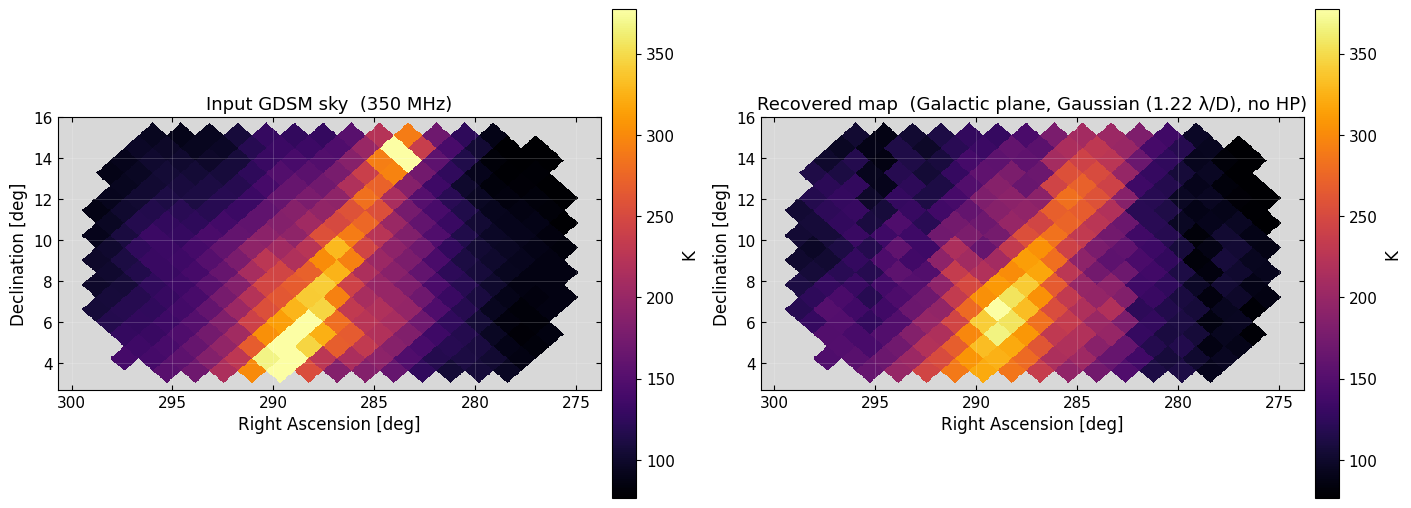

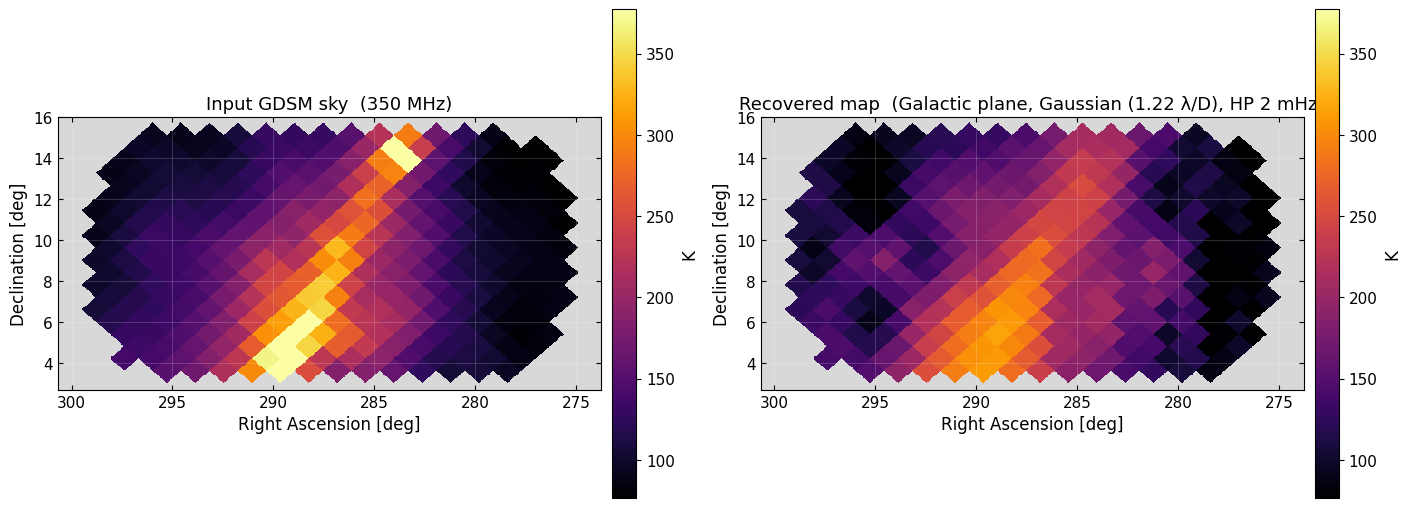

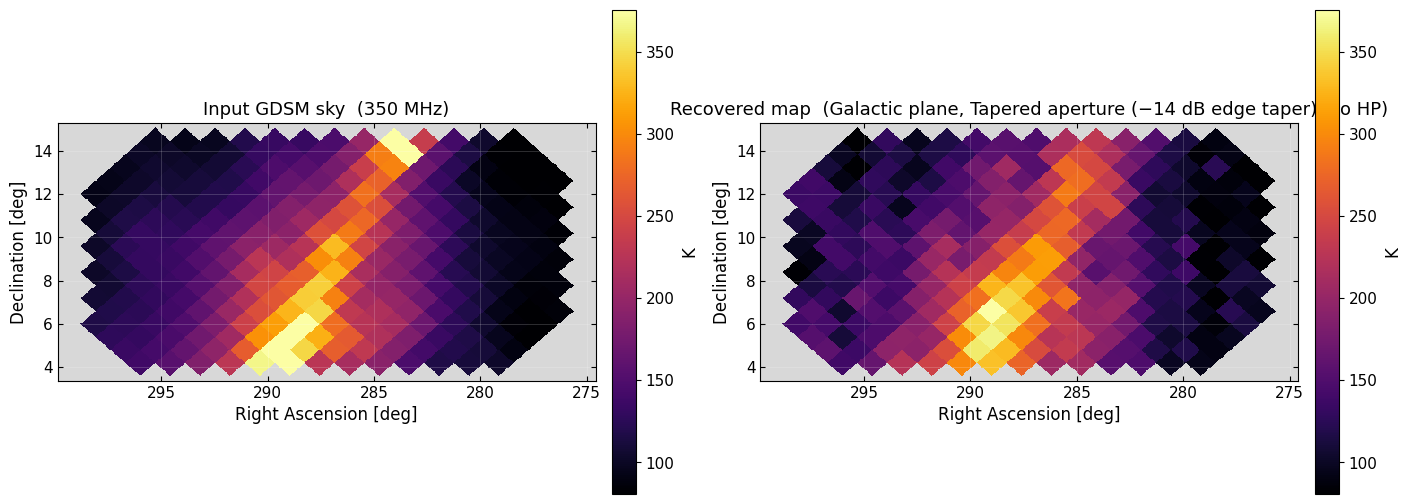

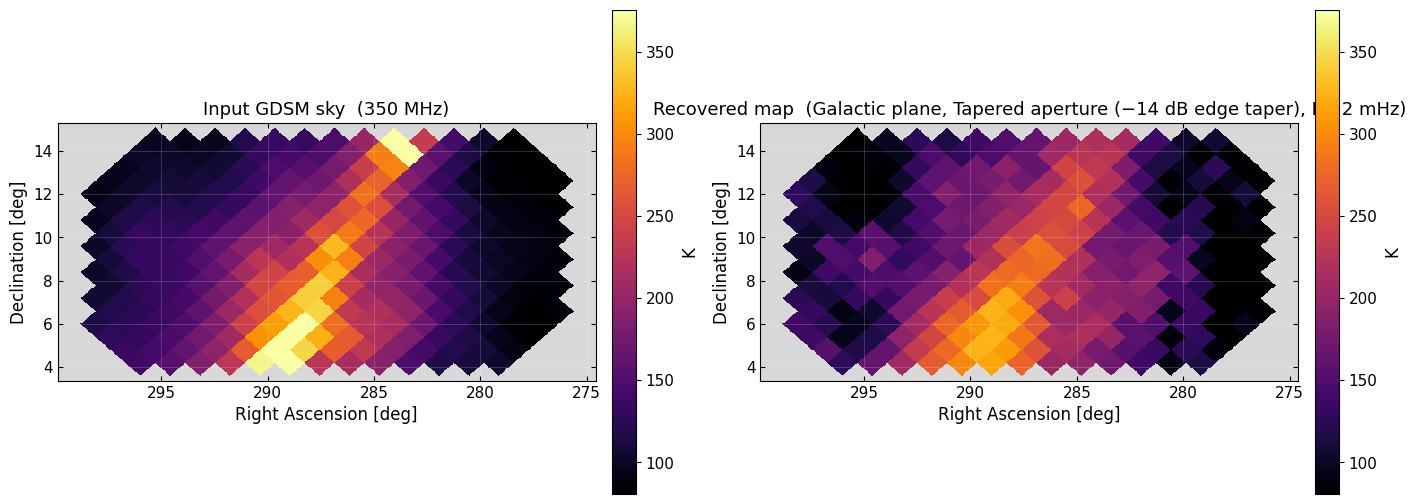

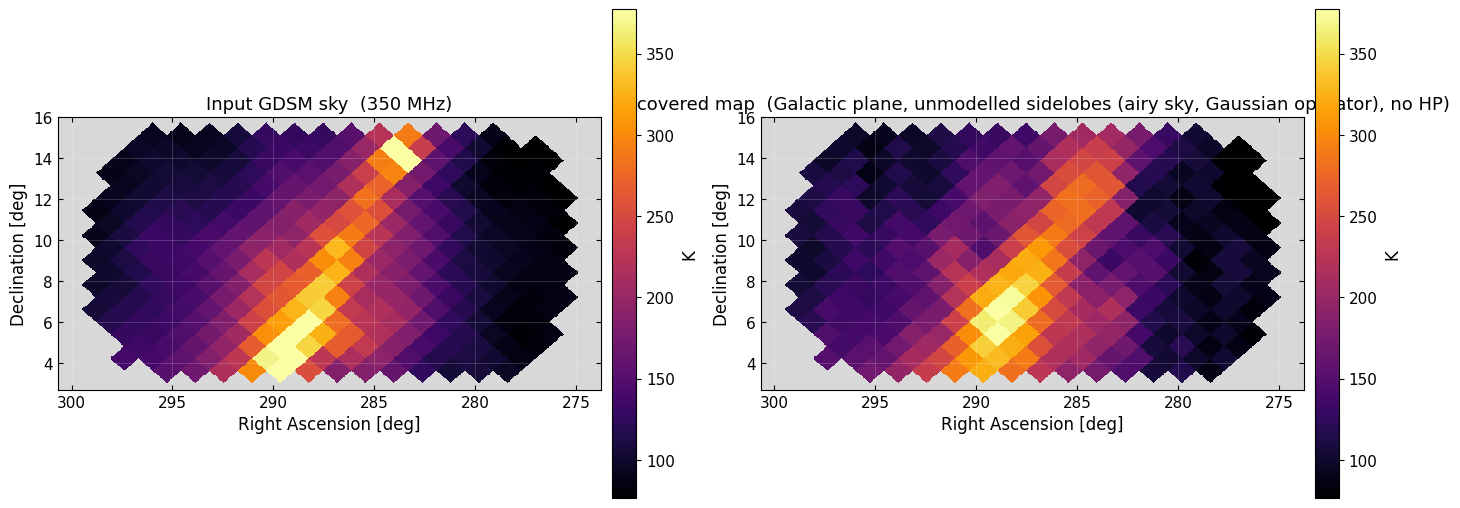

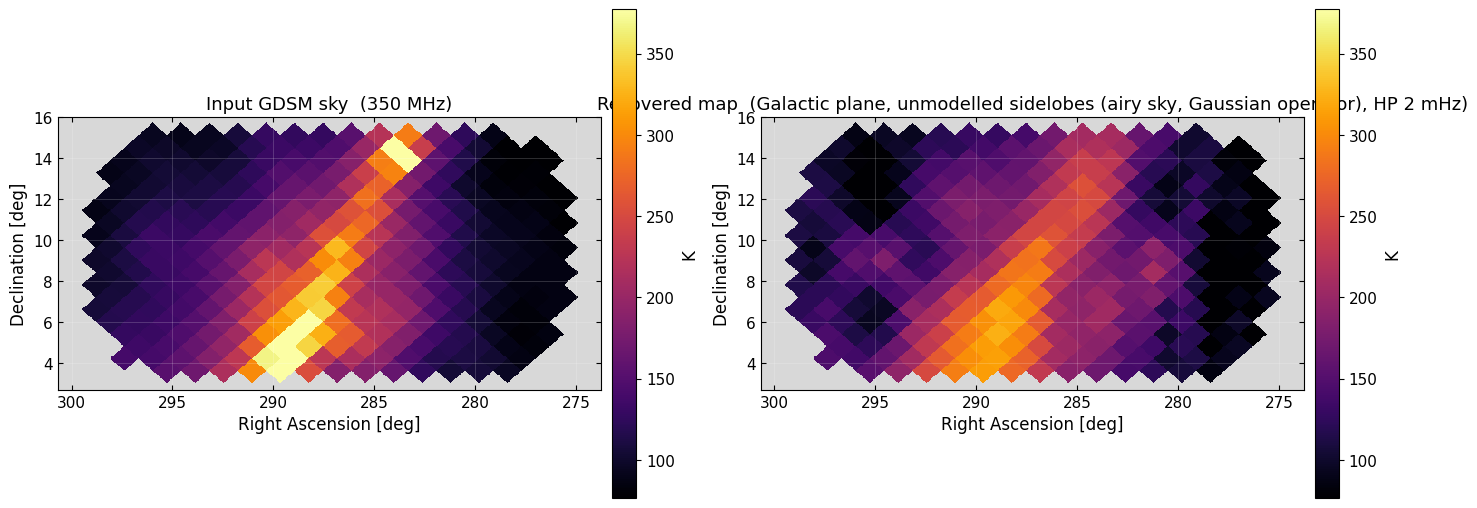

In [6]:
SCENARIO_LABELS = {
    "gauss": BEAMS["gauss"]["label"],
    "airy": BEAMS["airy"]["label"],
    "mismatch": "unmodelled sidelobes (airy sky, Gaussian operator)",
}
for tag, label in SCENARIO_LABELS.items():
    for hp_label, suffix in [("no HP", "noHP"), ("HP 2 mHz", "HP")]:
        fig = plot_map_compare(
            sky_est=results[(tag, hp_label)],
            sky_truth=truths[tag],
            nside=sky_Nside_map,
            pixel_indices=SCENARIO_PIX[tag],
            freq_mhz=freq_list[0],
            strategy_name=f"Galactic plane, {label}, {hp_label}",
            savepath=f"figures/map_ska_galplane_{tag}_{suffix}.png",
        )
        plt.show()


## How much of this is actually 1/f?

Experiment 002 concluded at b ≈ +50° that the 2 mHz high-pass helps, and it
does there. This section tests whether that carries over to the plane, where
the sky is ~10× brighter — and finds that it does not.

The key structural fact is that limTOD's 1/f is a **gain** term:
`TOD = (1 + g(t)) · (T_sky(t) + T_other) · (1 + η(t))`. The drift `g(t)` is
dimensionless, so the contamination it injects is `g(t)·T_sky(t)` — it scales
with sky brightness. Experiments 001/002 and 003 use the same seeds and the
same time grid, so `g(t)` is the *identical realization* in all of them and
the only thing that changes between the two LST windows is `T_sky`. That makes
this a controlled measurement of the brightness scaling.

Because `generate_TOD` draws the 1/f and white sequences from the seeded legacy
RNG in a fixed order, both can be replayed exactly, which lets the cached TODs
be split into sky / 1-f / white parts and re-solved with components switched
off one at a time — a proper map-space noise budget rather than a guess.

replay check (sample-to-sample rms of the TOD):
   raw cached TOD                  0.4858 K
   replayed white noise removed    0.1828 K   <- must drop
   independent draw removed        0.7004 K   <- must rise

 night   <T_sky>      g rms   1/f = g*T      white
     0    209.0 K  2.927e-04     54.1 mK    328.7 mK
     1    193.8 K  2.704e-04     55.6 mK    308.6 mK
     2    176.8 K  2.351e-04     37.1 mK    298.7 mK


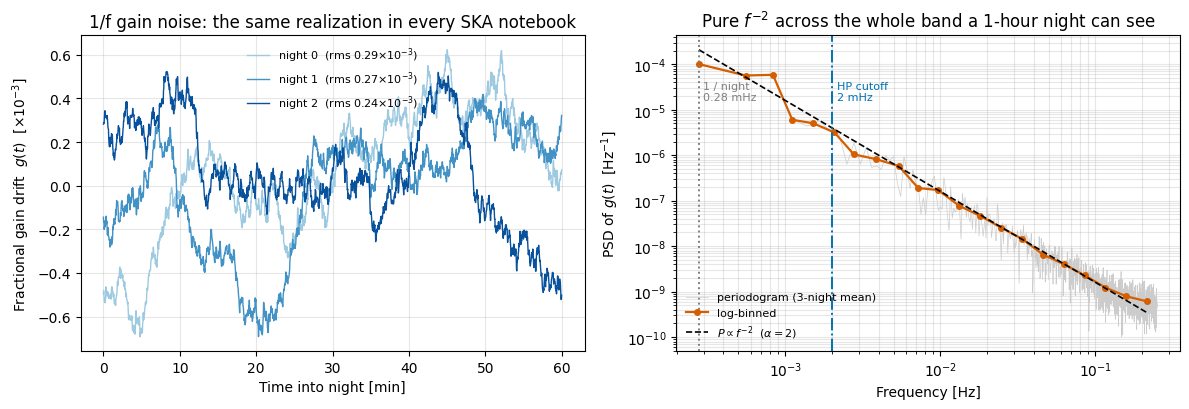


A 1-hour night resolves nothing below 0.28 mHz, so the 2 mHz cutoff sits 7x above the fundamental —
it removes the lowest ~7 Fourier modes of each night, which is where most of the sky's
large-scale structure along the drift also lives.


In [7]:
# --- 1/f study, part 1: recover the exact noise realizations -----------------
# TODSim's data model is multiplicative in the gain:
#     TOD = (1 + g(t)) * (T_sky(t) + T_other) * (1 + eta(t))
# generate_TOD draws g first (sim_noise -> flicker_model) and eta second, both
# from the seeded legacy RNG, so re-seeding with the same SEED + night and
# replaying those two draws reproduces the *exact* realizations baked into the
# cached TODs. That lets us split the cached TOD into sky / 1-f / white parts
# without re-running the (expensive) beam convolution.
from scipy import signal
from limTOD.flicker_model import sim_noise
from limTOD.HPW_filter import HP_filter_TOD

GAIN_NOISE_PARAMS = [1.335e-5, 1.099e-3, 2]   # generate_TOD default [f0, fc, alpha]
HP_CUTOFF = 2e-3                              # Hz, the notebook's "HP 2 mHz"

# Okabe-Ito (CVD-safe), assigned by role and used in fixed order throughout.
C_1F, C_WHITE, C_RECON, C_TOTAL = "#D55E00", "#0072B2", "#7F7F7F", "#000000"
C_PLANE, C_HIGHLAT = "#D55E00", "#0072B2"
NIGHT_COLORS = ["#9ecae1", "#4292c6", "#08519c"]

gain_noise, white_noise = [], []
for n in nights:
    np.random.seed(SEED + n["night"])
    gain_noise.append(sim_noise(*GAIN_NOISE_PARAMS, n["tlist"], n_samples=1,
                                white_n_variance=0.0)[0])
    white_noise.append(np.random.normal(0, np.sqrt(WHITE_VAR),
                                        size=(1, len(n["tlist"])))[0])

# Exact decomposition of the cached TODs.
sky_tod = {tag: [tod_data[tag]["TOD_group"][i]
                 / ((1 + gain_noise[i]) * (1 + white_noise[i]))
                 for i in range(len(nights))] for tag in tod_data}

# Sanity check that the replay is the *same* realization and not merely a
# statistically similar one: dividing out the replayed white noise must remove
# sample-to-sample scatter, whereas dividing out an independent draw of the
# same variance must add scatter. (The floor left behind is the sky TOD's own
# nside=64 pixelisation jitter, not a replay error.)
_o = tod_data["gauss"]["TOD_group"][0]
_ctrl = np.random.default_rng(12345).normal(0, np.sqrt(WHITE_VAR), _o.size)
print("replay check (sample-to-sample rms of the TOD):")
print(f"   raw cached TOD                  {np.diff(_o).std():.4f} K")
print(f"   replayed white noise removed    {np.diff(sky_tod['gauss'][0]).std():.4f} K"
      "   <- must drop")
print(f"   independent draw removed        {np.diff(_o/(1+_ctrl)).std():.4f} K"
      "   <- must rise")

print(f"\n{'night':>6s} {'<T_sky>':>9s} {'g rms':>10s} {'1/f = g*T':>11s} "
      f"{'white':>10s}")
for i, n in enumerate(nights):
    s = sky_tod["gauss"][i]
    print(f"{i:6d} {s.mean():8.1f} K {gain_noise[i].std():10.3e} "
          f"{(gain_noise[i]*s).std()*1e3:8.1f} mK "
          f"{(white_noise[i]*s).std()*1e3:8.1f} mK")

# --- Figure: the 1/f gain-noise realization and its spectrum -----------------
def log_binned_psd(freqs, psd, nbins=22):
    """Geometric-mean bin a periodogram so the power law is readable."""
    m = freqs > 0
    f, p = freqs[m], psd[m]
    edges = np.logspace(np.log10(f.min()), np.log10(f.max()), nbins + 1)
    idx = np.digitize(f, edges)
    fb, pb = [], []
    for k in range(1, nbins + 1):
        s = idx == k
        if s.any():
            fb.append(np.exp(np.mean(np.log(f[s]))))
            pb.append(p[s].mean())
    return np.array(fb), np.array(pb)


fig, (axa, axb) = plt.subplots(1, 2, figsize=(12, 4.2))

for i, n in enumerate(nights):
    axa.plot(np.arange(len(gain_noise[i])) * DT / 60.0,
             gain_noise[i] * 1e3, lw=1.0, color=NIGHT_COLORS[i],
             label=f"night {i}  (rms {gain_noise[i].std()*1e3:.2f}$\\times10^{{-3}}$)")
axa.set_xlabel("Time into night [min]")
axa.set_ylabel("Fractional gain drift  $g(t)$  [$\\times10^{-3}$]")
axa.set_title("1/f gain noise: the same realization in every SKA notebook")
axa.legend(fontsize=8, frameon=False)
axa.grid(alpha=0.3)

freqs, psd = signal.periodogram(np.array(gain_noise), fs=1.0 / DT,
                                detrend=False, axis=-1)
psd = psd.mean(0)
fb, pb = log_binned_psd(freqs, psd)
axb.loglog(freqs[1:], psd[1:], lw=0.5, color="0.8", label="periodogram (3-night mean)")
axb.loglog(fb, pb, "o-", ms=4, lw=1.6, color=C_1F, label="log-binned")
guide = pb[len(pb)//2] * (fb / fb[len(fb)//2]) ** -2.0
axb.loglog(fb, guide, "--", lw=1.2, color=C_TOTAL,
           label=r"$P \propto f^{-2}$  ($\alpha = 2$)")
f_night = 1.0 / (len(gain_noise[0]) * DT)
axb.axvline(f_night, color=C_RECON, ls=":", lw=1.4)
axb.axvline(HP_CUTOFF, color=C_WHITE, ls="-.", lw=1.4)
axb.annotate(f"1 / night\n{f_night*1e3:.2f} mHz", xy=(f_night, pb.max()*0.25),
             xytext=(3, 0), textcoords="offset points", fontsize=8,
             color=C_RECON, va="center")
axb.annotate(f"HP cutoff\n{HP_CUTOFF*1e3:.0f} mHz", xy=(HP_CUTOFF, pb.max()*0.25),
             xytext=(4, 0), textcoords="offset points", fontsize=8,
             color=C_WHITE, va="center")
axb.set_xlabel("Frequency [Hz]")
axb.set_ylabel(r"PSD of $g(t)$  [Hz$^{-1}$]")
axb.set_title("Pure $f^{-2}$ across the whole band a 1-hour night can see")
axb.legend(fontsize=8, frameon=False, loc="lower left")
axb.grid(alpha=0.3, which="both")

fig.tight_layout()
fig.savefig("figures/galplane_1f_noise_model.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"\nA 1-hour night resolves nothing below {f_night*1e3:.2f} mHz, so the "
      f"{HP_CUTOFF*1e3:.0f} mHz cutoff sits {HP_CUTOFF/f_night:.0f}x above the "
      f"fundamental —\nit removes the lowest ~{HP_CUTOFF/f_night:.0f} Fourier "
      "modes of each night, which is where most of the sky's\nlarge-scale "
      "structure along the drift also lives.")

loaded experiment-001 (b ~ +50deg) TODs for comparison


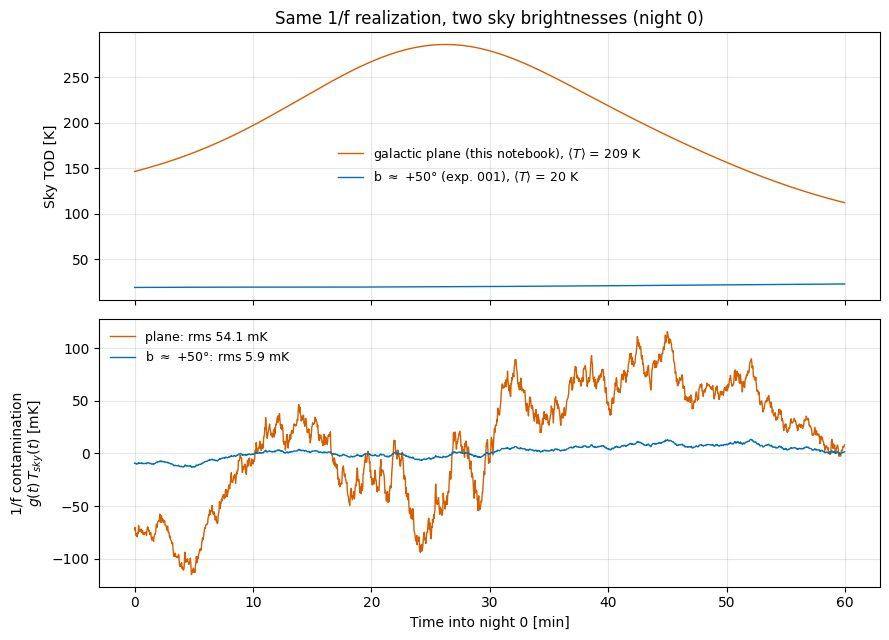


sky brighter by 10.4x -> 1/f contamination bigger by 9.2x. The gain
drift itself is bit-identical; only T_sky differs.


In [8]:
# --- 1/f study, part 2: why the plane is the hard case -----------------------
# The gain drift is *fractional*, so the contamination it injects is g(t) x
# T_sky(t) — it scales with how bright the sky is. Experiment 001/002 used the
# same seeds and the same time grid, so g(t) there is the identical realization
# and the only thing that changes is T_sky. Load that run's TODs for a
# controlled brightness comparison (skipped if the caches aren't present).
try:
    _hl = np.load("simulated_TODs_ska_drift_gauss.npz", allow_pickle=True)
    highlat_sky = [np.asarray(t, np.float64) / ((1 + gain_noise[i])
                                                * (1 + white_noise[i]))
                   for i, t in enumerate(_hl["TOD_group"])]
    print("loaded experiment-001 (b ~ +50deg) TODs for comparison")
except FileNotFoundError:
    highlat_sky = None
    print("experiment-001 TODs not found - skipping the high-latitude overlay")

fig, (axa, axb) = plt.subplots(2, 1, figsize=(9, 6.5), sharex=True,
                               height_ratios=[1, 1])
t_min = np.arange(len(sky_tod["gauss"][0])) * DT / 60.0

axa.plot(t_min, sky_tod["gauss"][0], lw=1.0, color=C_PLANE,
         label=f"galactic plane (this notebook), $\\langle T\\rangle$ = "
               f"{sky_tod['gauss'][0].mean():.0f} K")
if highlat_sky is not None:
    axa.plot(t_min, highlat_sky[0], lw=1.0, color=C_HIGHLAT,
             label=f"b $\\approx$ +50$\\degree$ (exp. 001), $\\langle T\\rangle$ = "
                   f"{highlat_sky[0].mean():.0f} K")
axa.set_ylabel("Sky TOD [K]")
axa.set_title("Same 1/f realization, two sky brightnesses (night 0)")
axa.legend(fontsize=9, frameon=False)
axa.grid(alpha=0.3)

c_plane = gain_noise[0] * sky_tod["gauss"][0]
axb.plot(t_min, c_plane * 1e3, lw=1.0, color=C_PLANE,
         label=f"plane: rms {c_plane.std()*1e3:.1f} mK")
if highlat_sky is not None:
    c_hl = gain_noise[0] * highlat_sky[0]
    axb.plot(t_min, c_hl * 1e3, lw=1.0, color=C_HIGHLAT,
             label=f"b $\\approx$ +50$\\degree$: rms {c_hl.std()*1e3:.1f} mK")
axb.set_xlabel("Time into night 0 [min]")
axb.set_ylabel("1/f contamination\n$g(t)\\,T_{sky}(t)$ [mK]")
axb.legend(fontsize=9, frameon=False)
axb.grid(alpha=0.3)

fig.tight_layout()
fig.savefig("figures/galplane_1f_contamination.png", dpi=200, bbox_inches="tight")
plt.show()

if highlat_sky is not None:
    print(f"\nsky brighter by {sky_tod['gauss'][0].mean()/highlat_sky[0].mean():.1f}x "
          f"-> 1/f contamination bigger by {c_plane.std()/c_hl.std():.1f}x. "
          "The gain\ndrift itself is bit-identical; only T_sky differs.")

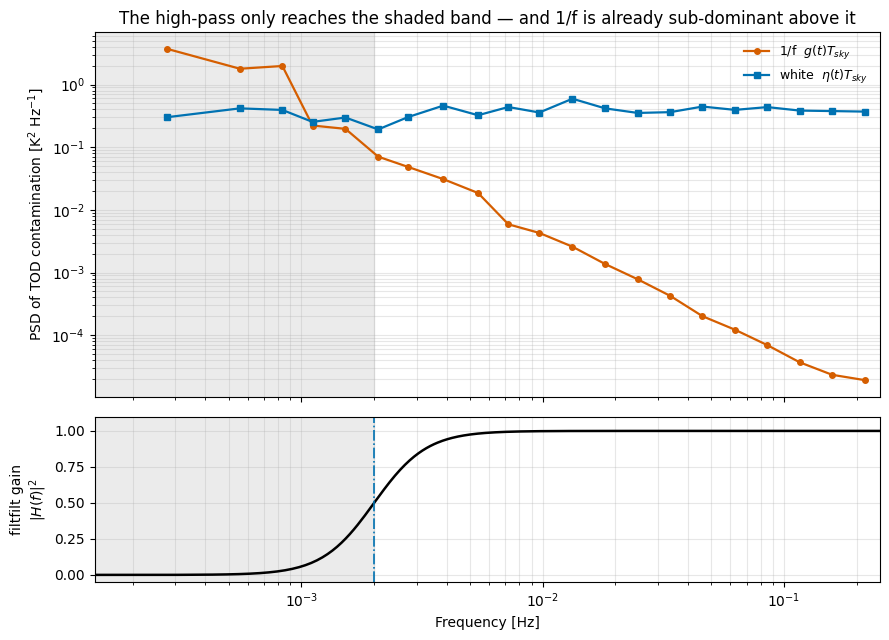

             rms before   rms after HP   surviving
1/f             54.1 mK        14.9 mK       27.6%
white          328.7 mK       329.3 mK      100.2%
pure drift      61.2 mK        13.8 mK       22.6%

'pure drift' is g(t) times a constant sky — the case the filter is designed for.
Against the real structured plane, more of the 1/f survives: the drift is
modulated up to higher frequencies by the sky it multiplies.


In [9]:
# --- 1/f study, part 3: what the high-pass can and cannot reach --------------
# Compare the *spectrum* of the 1/f contamination with the white-noise
# contamination, against the Butterworth response actually used by the
# map-maker (order 2, filtfilt -> the response is squared).
H_hp = HP_filter_TOD(len(gain_noise[0]), DT, cutoff_freq=HP_CUTOFF,
                     filter_order=2)

contam_1f = [gain_noise[i] * sky_tod["gauss"][i] for i in range(len(nights))]
contam_w = [white_noise[i] * sky_tod["gauss"][i] for i in range(len(nights))]

f_c, P_1f = signal.periodogram(np.array(contam_1f), fs=1/DT, detrend=False, axis=-1)
_, P_w = signal.periodogram(np.array(contam_w), fs=1/DT, detrend=False, axis=-1)
P_1f, P_w = P_1f.mean(0), P_w.mean(0)

fig, (axa, axb) = plt.subplots(2, 1, figsize=(9, 6.5), sharex=True,
                               height_ratios=[2.2, 1])

fb, pb = log_binned_psd(f_c, P_1f)
axa.loglog(fb, pb, "o-", ms=4, lw=1.6, color=C_1F, label="1/f  $g(t)T_{sky}$")
fb2, pb2 = log_binned_psd(f_c, P_w)
axa.loglog(fb2, pb2, "s-", ms=4, lw=1.6, color=C_WHITE,
           label=r"white  $\eta(t)T_{sky}$")
axa.axvspan(f_c[1] * 0.5, HP_CUTOFF, color="0.85", alpha=0.5, zorder=0)
axa.set_ylabel(r"PSD of TOD contamination [K$^2$ Hz$^{-1}$]")
axa.set_title("The high-pass only reaches the shaded band — and 1/f is already "
              "sub-dominant above it")
axa.legend(fontsize=9, frameon=False)
axa.grid(alpha=0.3, which="both")

w, h = signal.freqz(*signal.butter(2, HP_CUTOFF / (0.5 / DT), btype="high"),
                    worN=4096, fs=1.0 / DT)
axb.semilogx(w[1:], np.abs(h[1:]) ** 2, lw=1.8, color=C_TOTAL)
axb.axvspan(f_c[1] * 0.5, HP_CUTOFF, color="0.85", alpha=0.5, zorder=0)
axb.axvline(HP_CUTOFF, color=C_WHITE, ls="-.", lw=1.2)
axb.set_ylabel("filtfilt gain\n$|H(f)|^2$")
axb.set_xlabel("Frequency [Hz]")
axb.set_xlim(f_c[1] * 0.5, 0.5 / DT)
axb.set_ylim(-0.05, 1.1)
axb.grid(alpha=0.3, which="both")

fig.tight_layout()
fig.savefig("figures/galplane_1f_spectra.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"{'':10s} {'rms before':>12s} {'rms after HP':>14s} {'surviving':>11s}")
for lbl, c in [("1/f", contam_1f[0]), ("white", contam_w[0]),
               ("pure drift", gain_noise[0] * sky_tod["gauss"][0].mean())]:
    print(f"{lbl:10s} {c.std()*1e3:9.1f} mK {(H_hp@c).std()*1e3:11.1f} mK "
          f"{(H_hp@c).std()/c.std()*100:10.1f}%")
print("\n'pure drift' is g(t) times a constant sky — the case the filter is "
      "designed for.\nAgainst the real structured plane, more of the 1/f "
      "survives: the drift is\nmodulated up to higher frequencies by the sky "
      "it multiplies.")

regime          filter           total  recon floor        white          1/f     quad sum
galactic plane  no HP          23081.4      21368.0       7277.1       4770.1      23071.6
galactic plane  HP 2 mHz       31439.3      23426.0      19969.7       1869.1      30839.3
b = +50 deg     no HP           1299.9       1287.0        197.8        138.1       1309.4
b = +50 deg     HP 2 mHz        1173.6       1107.2        530.3         35.3       1228.1


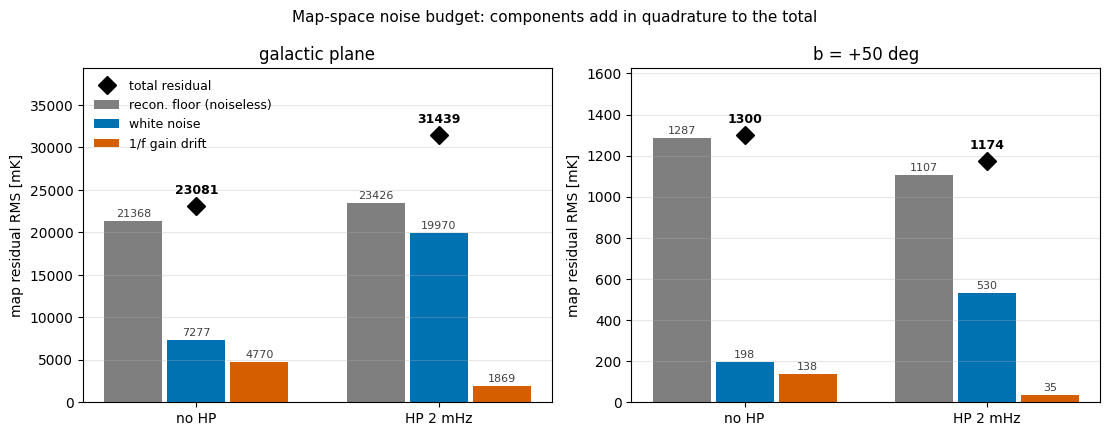

In [10]:
# --- 1/f study, part 4: the map-space noise budget ---------------------------
# Re-solve the map from TODs with components switched off one at a time. The
# difference between the "full" map and the "no 1/f" map is the map error
# caused by 1/f alone (same operator, mask, prior and white-noise realization).
_prior_cache = {}


def solve_variant(mm, TOD_group, assumed_fwhm_deg, cutoff=None, order=2):
    """The solve_both recipe, with the high-pass cutoff exposed."""
    pix = mm.pixel_indices
    sky_truth = sky_truth_full[pix]
    key = (id(mm), assumed_fwhm_deg)
    if key not in _prior_cache:
        _prior_cache[key] = hp.smoothing(
            sky_truth_full, fwhm=np.radians(assumed_fwhm_deg))[pix]
    prior_mean = _prior_cache[key]
    prior_inv_cov = np.ones_like(sky_truth) / max(float(np.std(sky_truth)), 1e-3)**2
    nv_floor = WHITE_VAR * (1e-3 * float(np.mean(sky_truth)))**2
    noise_variance = [WHITE_VAR * (np.asarray(op) @ sky_truth)**2 + nv_floor
                      for op in mm.Tsys_operators]
    kw = dict(TOD_group=TOD_group, dtime=DT, Tsky_prior_mean=prior_mean,
              Tsky_prior_inv_cov_diag=prior_inv_cov,
              noise_variance=noise_variance, regularization=1e-12,
              return_full_cov=False)
    if cutoff is not None:
        kw.update(use_high_pass=True,
                  cutoff_freq_group=np.array([cutoff] * len(TOD_group)),
                  filter_order=order)
    est, _ = mm(**kw)
    return est, sky_truth


def tod_variants(sky):
    """Switch each noise component on/off around a fixed sky TOD."""
    r = range(len(sky))
    return {
        "full":     [sky[i] * (1 + gain_noise[i]) * (1 + white_noise[i]) for i in r],
        "no 1/f":   [sky[i] * (1 + white_noise[i]) for i in r],
        "no white": [sky[i] * (1 + gain_noise[i]) for i in r],
        "clean":    [sky[i] for i in r],
    }


REGIMES = {"galactic plane": (mapmakers["gauss"], sky_tod["gauss"])}
if highlat_sky is not None:
    try:
        with open(f"mapmaker_ops_ska_drift_gauss_ns{sky_Nside_map}.pkl", "rb") as f:
            REGIMES["b = +50 deg"] = (pickle.load(f), highlat_sky)
    except FileNotFoundError:
        print("experiment-001 operator not found - budget shown for the plane only")

FWHM_G = BEAMS["gauss"]["fwhm"]
budget = {}
for reg, (mm, sky) in REGIMES.items():
    v = tod_variants(sky)
    for filt, cut in [("no HP", None), ("HP 2 mHz", HP_CUTOFF)]:
        est = {}
        for name, tg in v.items():
            e, truth = solve_variant(mm, tg, FWHM_G, cutoff=cut)
            est[name] = e
            budget[(reg, filt, name)] = float(np.std(e - truth) * 1e3)
        budget[(reg, filt, "1/f")] = float(np.std(est["full"] - est["no 1/f"]) * 1e3)
        budget[(reg, filt, "white")] = float(np.std(est["full"] - est["no white"]) * 1e3)

hdr = ("regime", "filter", "total", "recon floor", "white", "1/f", "quad sum")
print(f"{hdr[0]:15s} {hdr[1]:9s} " + " ".join(f"{h:>12s}" for h in hdr[2:]))
for reg in REGIMES:
    for filt in ("no HP", "HP 2 mHz"):
        tot = budget[(reg, filt, "full")]
        rec, wh, of = (budget[(reg, filt, k)] for k in ("clean", "white", "1/f"))
        qs = np.sqrt(rec**2 + wh**2 + of**2)
        print(f"{reg:15s} {filt:9s} " +
              " ".join(f"{x:12.1f}" for x in (tot, rec, wh, of, qs)))

# --- Figure: stacked-in-quadrature budget -----------------------------------
fig, axes = plt.subplots(1, len(REGIMES), figsize=(5.6 * len(REGIMES), 4.4))
axes = np.atleast_1d(axes)
comps = [("recon. floor (noiseless)", "clean", C_RECON),
         ("white noise", "white", C_WHITE),
         ("1/f gain drift", "1/f", C_1F)]
for ax, reg in zip(axes, REGIMES):
    filts = ["no HP", "HP 2 mHz"]
    x = np.arange(len(filts))
    w = 0.26
    for j, (lbl, key, col) in enumerate(comps):
        vals = [budget[(reg, f, key)] for f in filts]
        ax.bar(x + (j - 1) * w, vals, w * 0.92, color=col,
               label=lbl if ax is axes[0] else None)
        for xi, v in zip(x + (j - 1) * w, vals):
            ax.annotate(f"{v:.0f}", (xi, v), textcoords="offset points",
                        xytext=(0, 3), ha="center", fontsize=8, color="0.25")
    tot = [budget[(reg, f, "full")] for f in filts]
    ax.plot(x, tot, "D", ms=9, color=C_TOTAL, zorder=5,
            label="total residual" if ax is axes[0] else None)
    for xi, v in zip(x, tot):
        ax.annotate(f"{v:.0f}", (xi, v), textcoords="offset points",
                    xytext=(0, 9), ha="center", fontsize=9, weight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(filts)
    ax.set_ylabel("map residual RMS [mK]")
    ax.set_title(reg)
    ax.grid(alpha=0.3, axis="y")
    ax.set_ylim(0, max(tot + [budget[(reg, f, k)] for f in filts
                              for _, k, _ in comps]) * 1.25)
axes[0].legend(fontsize=9, frameon=False, loc="upper left")
fig.suptitle("Map-space noise budget: components add in quadrature to the total",
             fontsize=11)
fig.tight_layout()
fig.savefig("figures/galplane_1f_budget.png", dpi=200, bbox_inches="tight")
plt.show()

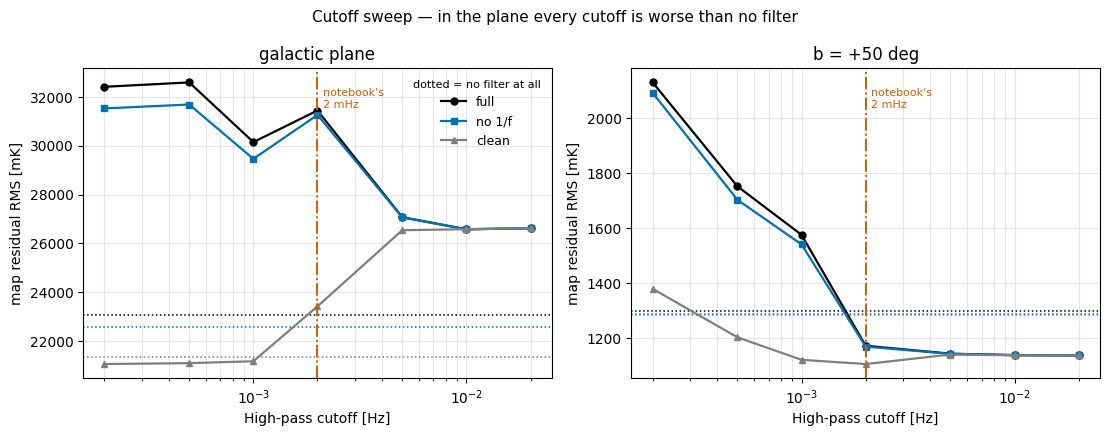

regime             best cutoff    best RMS   no filter
galactic plane            none  23081.4 mK  23081.4 mK
b = +50 deg             20 mHz   1138.2 mK   1299.9 mK


In [11]:
# --- 1/f study, part 5: is 2 mHz the right cutoff here? ----------------------
# Sweep the high-pass cutoff. "full" is the real TOD; "no 1/f" isolates what
# the filter costs when there is no drift to remove in the first place.
CUTOFFS = [None, 2e-4, 5e-4, 1e-3, 2e-3, 5e-3, 1e-2, 2e-2]
sweep = {}
for reg, (mm, sky) in REGIMES.items():
    v = tod_variants(sky)
    for c in CUTOFFS:
        for name in ("full", "no 1/f", "clean"):
            e, truth = solve_variant(mm, v[name], FWHM_G, cutoff=c)
            sweep[(reg, c, name)] = float(np.std(e - truth) * 1e3)

fig, axes = plt.subplots(1, len(REGIMES), figsize=(5.6 * len(REGIMES), 4.4))
axes = np.atleast_1d(axes)
x = np.array([c for c in CUTOFFS if c is not None])
for ax, reg in zip(axes, REGIMES):
    for name, col, mk in [("full", C_TOTAL, "o"), ("no 1/f", C_WHITE, "s"),
                          ("clean", C_RECON, "^")]:
        y = [sweep[(reg, c, name)] for c in CUTOFFS if c is not None]
        ax.semilogx(x, y, mk + "-", ms=5, lw=1.6, color=col, label=name)
        ax.axhline(sweep[(reg, None, name)], color=col, ls=":", lw=1.1)
    ax.axvline(HP_CUTOFF, color=C_1F, ls="-.", lw=1.4)
    ax.annotate("notebook's\n2 mHz", xy=(HP_CUTOFF, ax.get_ylim()[1]),
                xytext=(4, -14), textcoords="offset points", fontsize=8,
                color=C_1F, va="top")
    ax.set_xlabel("High-pass cutoff [Hz]")
    ax.set_ylabel("map residual RMS [mK]")
    ax.set_title(reg)
    ax.grid(alpha=0.3, which="both")
axes[0].legend(fontsize=9, frameon=False,
               title="dotted = no filter at all", title_fontsize=8)
fig.suptitle("Cutoff sweep — in the plane every cutoff is worse than no filter",
             fontsize=11)
fig.tight_layout()
fig.savefig("figures/galplane_1f_cutoff_sweep.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"{'regime':15s} {'best cutoff':>14s} {'best RMS':>11s} {'no filter':>11s}")
for reg in REGIMES:
    vals = {c: sweep[(reg, c, "full")] for c in CUTOFFS}
    best = min(vals, key=vals.get)
    lbl = "none" if best is None else f"{best*1e3:g} mHz"
    print(f"{reg:15s} {lbl:>14s} {vals[best]:8.1f} mK "
          f"{vals[None]:8.1f} mK")

rms_rows += [("--- 1/f budget ---", "")]
for reg in REGIMES:
    for filt in ("no HP", "HP 2 mHz"):
        rms_rows.append((f"{reg} / {filt}: 1/f-induced",
                         f"{budget[(reg, filt, '1/f')]:9.1f} mK"))
        rms_rows.append((f"{reg} / {filt}: recon floor",
                         f"{budget[(reg, filt, 'clean')]:9.1f} mK"))

### What the 1/f study shows

1. **1/f is not what limits this map.** The map residual decomposes (in
   quadrature, to <0.1%) into a **21.4 K noiseless reconstruction floor**,
   **7.3 K** from white noise and only **4.8 K** from 1/f. The 23 K total is
   dominated by the ill-conditioned inversion — 3 nights × 1 h of an
   uncross-linked drift scan constraining 321 pixels against a broad prior —
   not by the noise model.

2. **The brightness scaling is real and is the part the intuition got right.**
   The identical gain drift injects 54 mK of contamination in the plane versus
   5.9 mK at b ≈ +50°, tracking the 10× sky brightness. In map space it is
   worse than linear (4770 mK vs 138 mK, ~35×), because in the plane the drift
   multiplies a strongly *structured* signal and the product mimics real sky
   gradients along the scan.

3. **The 2 mHz high-pass does suppress 1/f — and still makes the map worse.**
   It cuts the 1/f-induced error by 61% (4770 → 1869 mK), but nearly triples
   the white-noise-induced error (7277 → 19970 mK) and lifts the reconstruction
   floor itself (21368 → 23426 mK). Net: 23.1 K → 31.4 K, a 36% *regression*.

4. **Why the filter backfires here.** A 1-hour night has a fundamental
   frequency of 0.28 mHz, so a 2 mHz cutoff removes the lowest ~7 Fourier modes
   of every scan. Those modes carry the plane's large-scale structure, and
   removing them from the operator as well as the data leaves the solve less
   constrained, so white noise is amplified into the map. At b ≈ +50° the sky
   has little large-scale structure to lose, so the same filter is a net win
   (1300 → 1174 mK, optimum near 20 mHz).

5. **Practical recommendation for this regime.** The cutoff sweep has no
   minimum below the unfiltered residual — *every* cutoff tested is worse than
   no filter at all. Keep `use_high_pass=False` for plane-crossing drift scans
   at this scan length, and spend the effort on cross-linking or a tighter
   prior instead; that is what the 21.4 K floor responds to. Revisit the
   high-pass only once the reconstruction floor is well below the 1/f term.

In [7]:
save_results_pdf(
    3, "galplane-drift-sidelobe-stress",
    "Galactic-plane sidelobe stress test: identical drift design, beams, "
    "noise seeds and map-making recipe as experiments 001/002, but the LST "
    f"window (start {START_UTC} UTC, LST ≈ 280°) sweeps the Dec ≈ +9° strip "
    "across the galactic plane (b = +7° → −6°, crossing at l ≈ 43°). "
    "Scenarios: matched Gaussian, matched tapered aperture, and beam "
    "mismatch (tapered-aperture sky through the Gaussian operator). The "
    "mismatch − gauss rows isolate the unmodelled-sidelobe map error "
    "(same operator, mask, prior and noise realization). A 1/f noise "
    "budget re-solves the map with the flicker and white components "
    "switched off one at a time: the residual is dominated by the "
    "noiseless reconstruction floor (21.4 K), not by 1/f (4.8 K), and "
    "the 2 mHz high-pass is a net regression in this regime.",
    ["figures/galplane_drift_tracks.png", "figures/galplane_tod_night0.png"]
    + [f"figures/map_ska_galplane_{t}_{s}.png"
       for t in ("gauss", "airy", "mismatch") for s in ("noHP", "HP")]
    + ["figures/galplane_1f_noise_model.png",
       "figures/galplane_1f_contamination.png",
       "figures/galplane_1f_spectra.png",
       "figures/galplane_1f_budget.png",
       "figures/galplane_1f_cutoff_sweep.png"],
    rms_table=rms_rows,
)


Archived results to results/003_galplane-drift-sidelobe-stress.pdf


'results/003_galplane-drift-sidelobe-stress.pdf'